<a href="https://colab.research.google.com/github/srivishnukaushal-lab/Main-Project-Decision-Making-With-Business-Statistics/blob/main/Main_Project_Decision_Making_With_Business_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

%matplotlib inline

# **Problem 1**

### **Business Context**

A physiotherapist with a male football team is interested in studying the relationship between foot injuries and the positions at which the players play from the data collected.

In [ ]:
# Printing out the given dataset

dataset = pd.DataFrame ([[45,56,24,20,145], [32,38,11,9,90], [77,94,35,29,235]], index = ["Players Injured", "Players not Injured", "Total"], columns = ["Striker", "Forward", "Attacking Midfielder", "Winger", "Total"])
dataset

,Striker,Forward,Attacking Midfielder,Winger,Total
Players Injured,45,56,24,20,145
Players not Injured,32,38,11,9,90
Total,77,94,35,29,235


### **Question 1.1**

What is the probability that a randomly chosen player would suffer an injury?

In [ ]:
# To answer this question, we can look at the total number of injured players in comparison to the total number of all players on the field.

P_injured_players = dataset['Total']['Players Injured'] / dataset['Total']['Total']

print ("Probability of a randomly chosen player suffering an injury is", round (P_injured_players, 2))

Probability of a randomly chosen player suffering an injury is 0.62


### **Question 1.2**

What is the probability that a player is a forward or a winger?

In [ ]:
# To answer this question, we look at the aggregate of players who play either as a forward or as a winger in comparison to the total number of all players on the field.
# We can also look at this as a union probability. This would mean we add up the individual probabilities of being a forward and being a winger, then subtract their intersection probability. In this case, these outcomes are mutually exclusive meaning their intersection probability is zero, therefore the union probability is just the sum of the individual probabilities.

P_forward_or_winger = (dataset['Forward']['Total'] + dataset['Winger']['Total']) / dataset['Total']['Total']

print ("Probability of a randomly chosen player being a forward or a winger is", round (P_forward_or_winger, 2))

Probability of a randomly chosen player being a forward or a winger is 0.52


### **Question 1.3**

What is the probability that a randomly chosen player plays in a striker position and has a foot injury?

In [ ]:
# To answer this question, we look at the number of injured players who play in the striker position in comparison to the total number of all players on the field.

P_injured_strikers = dataset['Striker']['Players Injured'] / dataset['Total']['Total']

print ("Probability of a randomly chosen player being a striker and having a foot injury is", round (P_injured_strikers, 2))

Probability of a randomly chosen player being a striker and having a foot injury is 0.19


### **Question 1.4**

What is the probability that a randomly chosen injured player is a striker?

In [ ]:
# This question sounds very similar to the last but there is a crucial difference. The sample size over here is the total number of injured players and not the total number of all players on the field as it was previously. We are looking at a conditional probability.
# To answer this question, we look at the total number of injured strikers in comparison to the total number of injured players.

P_injured_strikers_conditional = dataset['Striker']['Players Injured'] / dataset['Total']['Players Injured']

print ("Probability of a randomly chosen injured player being a striker is", round (P_injured_strikers_conditional, 2))

Probability of a randomly chosen injured player being a striker is 0.31


# **Problem 2**

### **Business Context**

The breaking strength of gunny bags used for packaging cement is normally distributed with a mean of 5 kg per sq. centimeter and a standard deviation of 1.5 kg per sq. centimeter. The quality team of the cement company wants to know the following about the packaging material to better understand wastage or pilferage within the supply chain.

### **Question 2.1**

What proportion of the gunny bags have a breaking strength of less than 3.17 kg per sq cm?

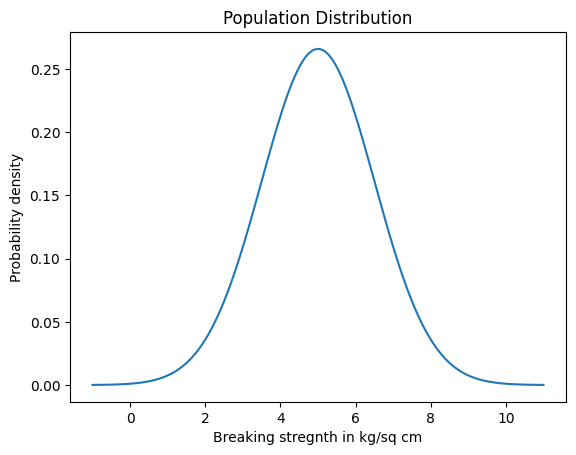

In [ ]:
# We know from the business context that Mu (population mean) is 5 and Sigma (population standard deviation) is 1.5.

from scipy.stats import norm

Mu, Sigma = 5, 1.5

# 99.7% of all values fall within 3 standard deviations of the mean in a normal distribution, and hence to reasonably cover all values, we're going with a range that covers 4 standard deviations on either side of the mean.

x_values = np.linspace (Mu - (4 * Sigma), Mu + (4 * Sigma), 1000)

# Now let's reconstruct the normal distribution that has these parameters.

population_distribution = norm.pdf (x_values, loc = 5, scale = 1.5)
plt.plot (x_values, population_distribution)
plt.xlabel ("Breaking stregnth in kg/sq cm")
plt.ylabel ("Probability density")
plt.title ("Population Distribution")
plt.show()

In [ ]:
# Now to answer the question, we will look at the Cumulative Distribution Function (CDF) of 3.17 from the population distribution, which will give us the proportion of gunny bags that have a breaking stregnth of less than 3.17 kg / sq cm.

CDF_3_point_17 = norm.cdf (3.17, Mu, Sigma)
print ("The proportion of gunny bags that have a breaking strength of less than 3.17 kg per sq cm is", round (CDF_3_point_17,2))

The proportion of gunny bags that have a breaking strength of less than 3.17 kg per sq cm is 0.11


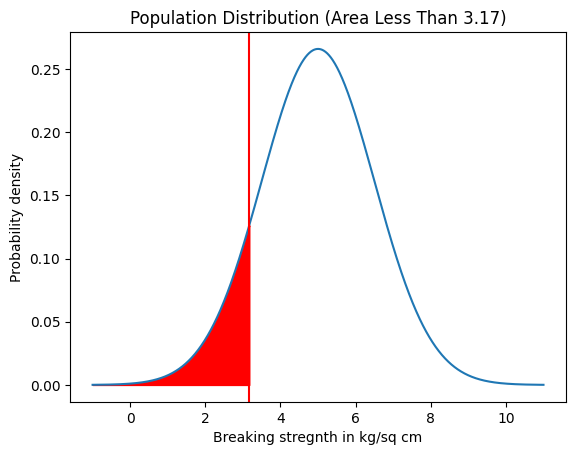

In [ ]:
# Let's also visualise this proportion on the same population distribution to get a more intuitive understanding.

plt.plot (x_values, population_distribution)

# Drawing a line at 3.17 and shading the area beneath:

plt.axvline(x=3.17, c="r")
shaded_area = np.linspace (Mu - (4 * Sigma), 3.17, 300)
plt.fill_between(shaded_area, norm.pdf(shaded_area, Mu, Sigma), color="r")

# Regular plot labels:

plt.xlabel ("Breaking stregnth in kg/sq cm")
plt.ylabel ("Probability density")
plt.title ("Population Distribution (Area Less Than 3.17)")
plt.show()

### **Question 2.2**

What proportion of the gunny bags have a breaking strength of at least 3.6 kg per sq cm.?

In [ ]:
# To answer this question, we will do 1 minus the CDF of 3.6 from the same population distribution as we want to know the proportion of bags that have a breaking stregnth of atleast (and not less than) 3.6 kg per sq cm.

CDF_inverse_3_point_6 = 1 - norm.cdf (3.6, Mu, Sigma)

print ("The proportion of gunny bags that have a breaking strength of atleast 3.6 kg per sq cm is", round (CDF_inverse_3_point_6,2))

The proportion of gunny bags that have a breaking strength of atleast 3.6 kg per sq cm is 0.82


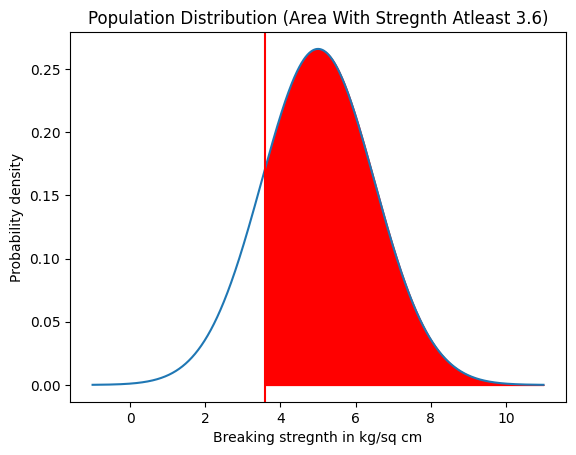

In [ ]:
# Let's visualise this again to get a more intuitive understanding of the proportion.

plt.plot (x_values, population_distribution)

# Drawing a line at 3.6 and shading the area beneath on the right of it:

plt.axvline(x=3.6, c="r")
shaded_area = np.linspace (3.6, Mu + (4 * Sigma), 600)
plt.fill_between(shaded_area, norm.pdf(shaded_area, Mu, Sigma), color="r")

# Regular plot labels:

plt.xlabel ("Breaking stregnth in kg/sq cm")
plt.ylabel ("Probability density")
plt.title ("Population Distribution (Area With Stregnth Atleast 3.6)")
plt.show()

# As we can see, it is a majority proportion and is significant.

### **Question 2.3**

What proportion of the gunny bags have a breaking strength between 5 and 5.5 kg per sq cm.?

In [ ]:
# To answer this question, we will find the difference between the CDFs of 5.5 and 5 from the same population distribution.

CDF_between_5_5_point_5 = norm.cdf (5.5, Mu, Sigma) - norm.cdf (5, Mu, Sigma)

print ("The proportion of gunny bags that have a breaking strength between 5 and 5.5 kg per sq cm is", round (CDF_between_5_5_point_5,2))

The proportion of gunny bags that have a breaking strength between 5 and 5.5 kg per sq cm is 0.13


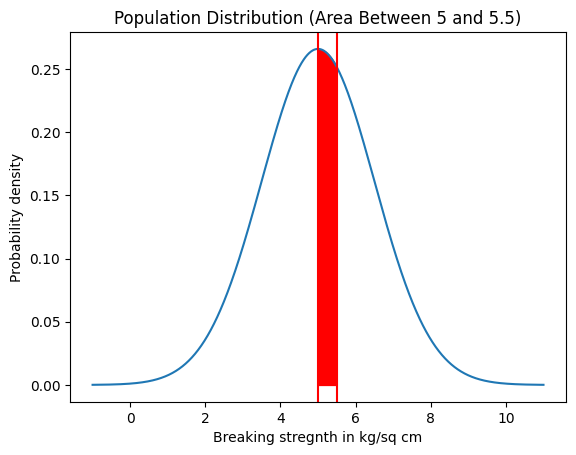

In [ ]:
# Let's visualise this proportion again.

plt.plot (x_values, population_distribution)

# Drawing lines at 5 and 5.5, and shading the area between them:

plt.axvline(x=5, c="r")
plt.axvline(x=5.5, c="r")
shaded_area = np.linspace (5, 5.5, 200)
plt.fill_between(shaded_area, norm.pdf(shaded_area, Mu, Sigma), color="r")

# Regular plot labels:

plt.xlabel ("Breaking stregnth in kg/sq cm")
plt.ylabel ("Probability density")
plt.title ("Population Distribution (Area Between 5 and 5.5)")
plt.show()

# As we can see, this proportion is a small one that is placed in proximity to the mean.

### **Question 2.4**

What proportion of the gunny bags have a breaking strength NOT between 3 and 7.5 kg per sq cm.?

In [ ]:
# To answer this question, we can take two approaches: find CDF of 3 and add with 1 minus CDF of 7.5, or, find CDF of 7.5 minus CDF of 3 and do 1 minus that. We will do the latter.

CDF_not_between_3_7_point_5 = 1 - (norm.cdf (7.5, Mu, Sigma) - norm.cdf (3, Mu, Sigma))

print ("The proportion of gunny bags that have a breaking strength NOT between 3 and 7.5 kg per sq cm is", round (CDF_not_between_3_7_point_5, 2))

The proportion of gunny bags that have a breaking strength NOT between 3 and 7.5 kg per sq cm is 0.14


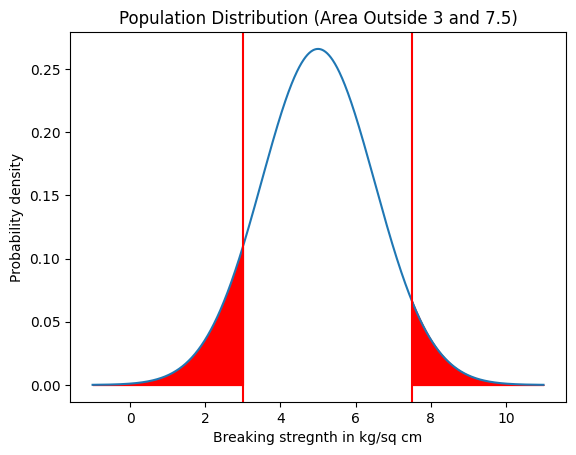

In [ ]:
# Let's visualise this on the population distribution, it should give us two shaded regions on either side of the specified range.

plt.plot (x_values, population_distribution)

# Drawing lines at 3 and 7.5, and shading the areas on either side of them:

plt.axvline (x=3, c="r")
plt.axvline (x=7.5, c="r")
shaded_area_1 = np.linspace (Mu - 4*Sigma, 3, 300)
shaded_area_2 = np.linspace (7.5, Mu + 4*Sigma, 300)
plt.fill_between (shaded_area_1, norm.pdf (shaded_area_1, Mu, Sigma), color="r")
plt.fill_between (shaded_area_2, norm.pdf (shaded_area_2, Mu, Sigma), color="r")

# Regular plot labels:

plt.xlabel ("Breaking stregnth in kg/sq cm")
plt.ylabel ("Probability density")
plt.title ("Population Distribution (Area Outside 3 and 7.5)")
plt.show()



# **Problem 3**

### **Business Context**

Zingaro stone printing is a company that specializes in printing images or patterns on polished or unpolished stones. However, for the optimum level of printing of the image, the stone surface has to have a Brinell's hardness index of at least 150. Recently, Zingaro has received a batch of polished and unpolished stones from its clients. We will assume a 5% significance level.

In [ ]:
# Mounting the given dataset onto Colab:

from google.colab import drive
drive.mount ("/content/drive")

dataset = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Zingaro_Company.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Before heading to the questions, let's quickly get a summary of our dataset.

dataset.shape

# We see that the data has two columns (Unpolished, and Treated and Polished), and 75 rows. This means our SAMPLE SIZE is 75.

(75, 2)

In [ ]:
dataset.head()

,Unpolished,Treated and Polished
0,164.481713,133.209393
1,154.307045,138.482771
2,129.861048,159.665201
3,159.096184,145.663528
4,135.256748,136.789227


In [ ]:
dataset.tail()

# From the head and the tail of the dataset, we get a look at some of the values. We see that they denote the Brinell's hardness index of each observation that is relevent to our problem.

,Unpolished,Treated and Polished
70,123.067611,142.293544
71,171.822218,140.124092
72,88.135994,141.393091
73,145.150397,131.370530
74,170.854823,144.502647


In [ ]:
dataset.min()

,0
Unpolished,48.406838
Treated and Polished,107.524167


In [ ]:
dataset.max()

# From the min and max of the dataset, we see the Brinell's hardness index ranges from 48 to 200 in the unpolished category and between 107 and 192 on the polished category. These are the limits of our dataset.

,0
Unpolished,200.161313
Treated and Polished,192.272856


In [ ]:
dataset.info ()

# Based on the info from the dataset, we see there are no errors to be fixed.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unpolished            75 non-null     float64
 1   Treated and Polished  75 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB


### **Question 3.1**

Zingaro has reason to believe that the unpolished stones may not be suitable for printing. Do you think Zingaro is justified in thinking so?

In [ ]:
# We are given the information that the Brinell's hardness index has to be atleast 150 to be suitable for printing.
# What we need to essentially do over here is see if the mean of our sample (unpolished stones) deviates from this figure of 150 by more than what we are willing to tolerate (specified by our significance level which is also given to be 5%) on the sampling distribution of the population.
# By looking at the sample, we are trying to determine if the population that it comes from may or may not be suitable for printing.

# In this case, we have access to our ideal population mean (atleast 150), but no access to the population standard deviation. Hence, we will model our sampling distribution using the t-distribution.
# The t-distribution works in this case because the sample size is greater than 30 (it is 75).

from scipy.stats import t


In [ ]:
# Let's start by defining our null and alternative hypotheses.

"H0: Mu >= 150" # This is the null hypothesis. This means the stones ARE fit for printing.
"Ha: Mu < 150"  # This is the alternative hypothesis. This means the stones are NOT fit for printing.

# This is a one-tailed hypothesis test since we only reject the null if the sample mean is too low. If it is higher, that doesn't constitute a rejection.

print ("H0: Mu >= 150", "\n", "Ha: Mu < 150")

H0: Mu >= 150 
 Ha: Mu < 150


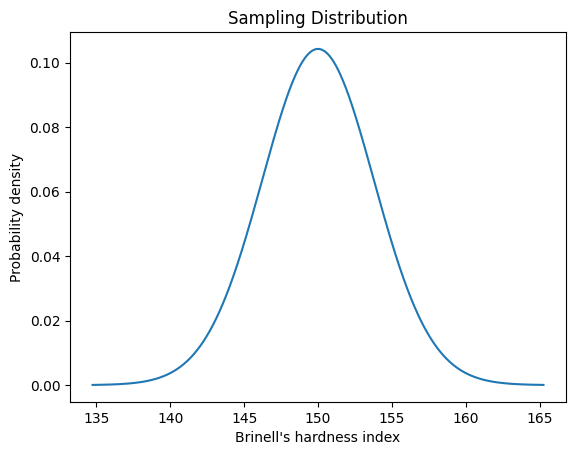

In [ ]:
# Now let's construct the sampling distribution of the population distribution around our ideal mean.
# The principles using which we do this come from the Central Limit Theorem.

Mu = 150                              # Ideal population mean
S = dataset['Unpolished ']. std()     # Sample standard deviation
n = 75                                # Sample size

x_values = np.linspace (150 - 4*S/np.sqrt(n), 150 + 4*S/np.sqrt(n), 1000)  # Using S/np.sqrt(n) here because that is the standard deviation of the sampling distribution.

sampling_distribution = t.pdf (x_values, n-1, Mu, S/np.sqrt(n))  # Degree of freedom is n-1.

# Now let's visualise this sampling distribution.

plt.plot (x_values, sampling_distribution)
plt.xlabel ("Brinell's hardness index")
plt.ylabel ("Probability density")
plt.title ("Sampling Distribution")
plt.show()



In [ ]:
# Now, let's define our tolerance range within this sampling distribution at a significance level of 5%.
# Because the hypothesis test is one-tailed, the rejection region will only be on the lower end.

lower_end = t.ppf (0.05, n-1, Mu, S/np.sqrt(n))

print ("Tolerance range is everything above", round (lower_end, 2), "on the Brinell's hardness index")

Tolerance range is everything above 143.64 on the Brinell's hardness index


In [ ]:
# Where does our sample mean fall in relation to this range?

x_bar = dataset["Unpolished "].mean()
round (float(x_bar), 2)

# We see that the sample mean of 134.11 is beneath our tolerance range of everything above 143.64.
# Therefore, we can conclude that we have sufficient evidence to reject the null hypothesis.

134.11

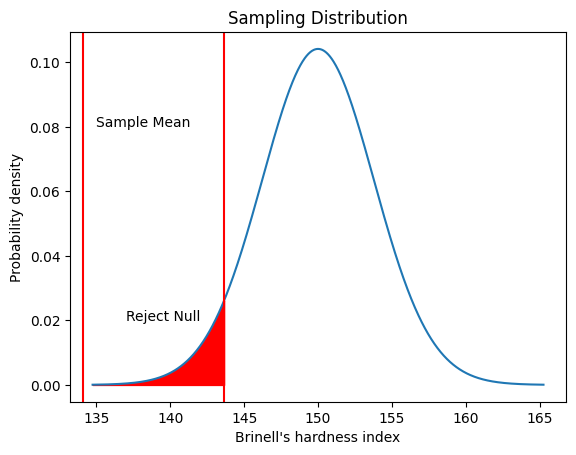

In [ ]:
# Before we conclude, let's quickly visualise the rejection region and the sample mean on the sampling distribution.

plt.plot (x_values, sampling_distribution)

# Drawing a lines at 143.64, and shading the area under it:

plt.axvline(x=143.64, c="r")
shaded_area = np.linspace (Mu-4*S/np.sqrt(n), 143.64, 200)
plt.fill_between(shaded_area, t.pdf(shaded_area, n-1, Mu, S/np.sqrt(n)), color="r")

# Drawing a line at our sample mean of 134.11 and adding labels for the sample mean and rejection region:

plt.axvline(x=134.11, c="r")
plt.annotate('Reject Null', (137, 0.02))
plt.annotate('Sample Mean', (135, 0.08))

# Regular plot labels:

plt.xlabel ("Brinell's hardness index")
plt.ylabel ("Probability density")
plt.title ("Sampling Distribution")
plt.show()

Conclusion:

- Sample means falls outside of tolerance range of sampling distribution as specified by the signifance level.
- This means we have sufficient evidence to reject the null hypothesis.
- We can say the Zingaro Company is in fact justified in thinking that their unpolished stones are unsuitable for printing.

### **Question 3.1 (Alternative Approach with Standardising and p-value)**

In [ ]:
# Once we have the sampling distribution, we can standardise it and find the p-value of our sample mean.
# If the p-value is less than our significance level of 5%, we can reject the null hypothesis.

z_score_sample_mean = (x_bar - Mu) / (S/np.sqrt(n))

p_value = t.cdf (z_score_sample_mean, n-1, 0, 1)
p_value

# As we can see, the p_value is extremely small and significantly lesser than our significance value of 5%.
# Therefore, we can reject the null hypothesis.
# This alternative approach with stadardising and p-value has led us to the same conclusions as our initial approach, establishing their validity.

np.float64(4.1712869974196425e-05)

In [ ]:
# By the way, the p_value of our original sample mean before standardising would be the exact same thing, leading us to the same conclusion:

t.cdf (x_bar, n-1, Mu, S/np.sqrt(n))

np.float64(4.1712869974196425e-05)

### **Question 3.2**

Is the mean hardness of the polished and unpolished stones the same?

In [ ]:
# Let's again start by defining our null and alternative hypotheses.

"H0: Mu1 = Mu2" # This is the null hypothesis. This means the unpolished and polished stones DO come from similar populations.
"Ha: Mu1 ≠ Mu2"  # This is the alternative hypothesis. This means the unpolished and polished stones DO NOT come from similar populations.

# This is a two-tailed hypothesis test since we are looking at inequality in the alternative hypothesis.
# We are essentially checking to see if the two sample means likely belong to the same sampling distribution or not.

print ("H0: Mu1 = Mu2", "\n", "Ha: Mu1 ≠ Mu2")

H0: Mu1 = Mu2 
 Ha: Mu1 ≠ Mu2


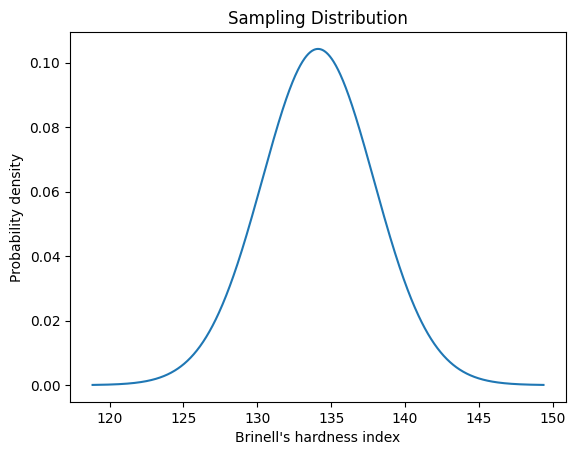

In [ ]:
# Let's construct a sampling distribution around our sample mean of unpolished stones.
# Again, the principles using which we do this come from the Central Limit Theorem.

x_bar_1 = dataset['Unpolished ']. mean()    # Sample mean
S = dataset['Unpolished ']. std()         # Sample standard deviation
n = 75                                    # Sample size

x_values = np.linspace (x_bar_1 - 4*S/np.sqrt(n), x_bar_1 + 4*S/np.sqrt(n), 1000)  # Using S/np.sqrt(n) here because that is the standard deviation of the sampling distribution.

sampling_distribution = t.pdf (x_values, n-1, x_bar_1, S/np.sqrt(n))  # Degree of freedom is n-1.

# Now let's visualise this sampling distribution.

plt.plot (x_values, sampling_distribution)
plt.xlabel ("Brinell's hardness index")
plt.ylabel ("Probability density")
plt.title ("Sampling Distribution")
plt.show()

In [ ]:
# Now, let's define our tolerance range within this sampling distribution at a significance level of 5%.
# Because the hypothesis test is two-tailed, the rejection region will be on both sides of the tolerance range.

lower_end = t.ppf (0.025, n-1, x_bar_1, S/np.sqrt(n))
upper_end = t.ppf (0.975, n-1, x_bar_1, S/np.sqrt(n))

print ("Tolerance range is everything between", round (lower_end, 2), "and", round (upper_end, 2), "on the Brinell's hardness index")

Tolerance range is everything between 126.51 and 141.71 on the Brinell's hardness index


In [ ]:
# Where does the sample mean of polished stones fall in relation to this range?

x_bar_2 = dataset["Treated and Polished"].mean()
round (float(x_bar_2), 2)

# We see that the sample mean of polished stones which is 147.79 is outside our tolerance range of 126.51 and 141.71.
# Therefore, we can conclude that we have sufficient evidence to reject the null hypothesis.

147.79

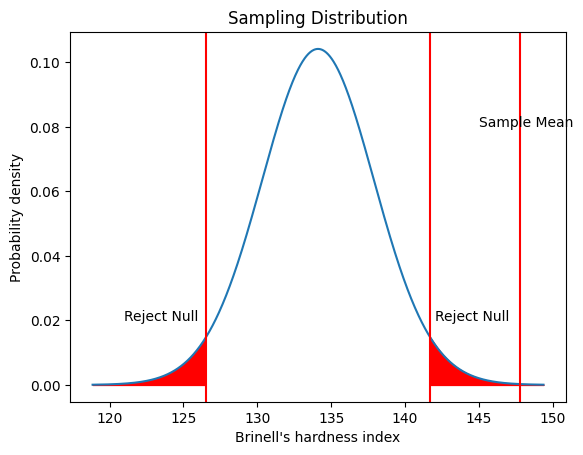

In [ ]:
# Again, before we conclude, let's quickly visualise the rejection region and the sample mean of polished stones on the sampling distribution of unpolished stones.

plt.plot (x_values, sampling_distribution)

# Drawing lines at 126.51 and 141.71, and shading the areas outside of them (rejection regions):

plt.axvline(x=126.51, c="r")
plt.axvline(x=141.71, c="r")
shaded_area_1 = np.linspace (x_bar_1 - (4*S/np.sqrt(n)), 126.51, 200)
shaded_area_2 = np.linspace (141.71, x_bar_1 + (4*S/np.sqrt(n)), 200)
plt.fill_between(shaded_area_1, t.pdf(shaded_area_1, n-1, x_bar_1, S/np.sqrt(n)), color="r")
plt.fill_between(shaded_area_2, t.pdf(shaded_area_2, n-1, x_bar_1, S/np.sqrt(n)), color="r")

# Drawing a line at 147.79 (sample mean of polished stones), and adding labels for the sample mean of polished stones and rejection regions:

plt.axvline(x=147.79, c="r")
plt.annotate('Reject Null', (142, 0.02))
plt.annotate('Reject Null', (121, 0.02))
plt.annotate('Sample Mean', (145, 0.08))

# Regular plot labels:

plt.xlabel ("Brinell's hardness index")
plt.ylabel ("Probability density")
plt.title ("Sampling Distribution")
plt.show()

Conclusion:

- Sample means of polished stones falls outside of tolerance range of sampling distribution of unpolished stones as specified by the signifance level.
- This means we have sufficient evidence to reject the null hypothesis.
- We can say that the mean hardness of unpolished and polished stones are likely not the same and that they come from different populations.

### **Question 3.2 (Alternative Approach with Interval Estimation)**

In [ ]:
# Let's build a 95% confidence interval around the sample mean of unpolished stones (since significance level is 5%)

con_int = t.interval (0.95, n-1, x_bar_1, S/np.sqrt(n))
con_int

# This gives us the exact same tolerance range as from our previous approach.
# Now we can compare the sample mean of polished stones (147.79) to this and see that it falls outside this range.
# This approach brings us to the same conclusions as well, establishing their validity.

(np.float64(126.50829775780252), np.float64(141.71275530966412))

# **Problem 4**

### **Business Context**

Dental implant data: The hardness of metal implants in dental cavities depends on multiple factors, such as the method of implant, the temperature at which the metal is treated, the alloy used as well as the dentists who may favor one method above another and may work better in his/her favorite method. The response is the variable of interest.

In [ ]:
# Mounting the dataset onto Colab:

dataset = pd.read_excel("/content/drive/My Drive/Colab Notebooks/Dental Hardness data.xlsx")

### **Question 4.1**

How does the hardness of implants vary depending on dentists?

In [ ]:
# We're trying to see if the hardness of implants does actually differ depending on the dentist.

# Starting with an overview of the dataset:

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Dentist   90 non-null     int64
 1   Method    90 non-null     int64
 2   Alloy     90 non-null     int64
 3   Temp      90 non-null     int64
 4   Response  90 non-null     int64
dtypes: int64(5)
memory usage: 3.6 KB


In [ ]:
# We are also told we must conduct the analysis for the different alloys seperately. Let's look at how many alloys there are:

dataset['Alloy'].value_counts()

# There are two alloys, each used with 45 implants.

,count
Alloy,
1,45
2,45


In [ ]:
# Let's look at the number of implants for each dentist:

dataset['Dentist'].value_counts()

# From this, we can see that the number of implants done by each dentist is the same, or in other words, the SAMPLE SIZE is consistent.

,count
Dentist,
1,18
2,18
3,18
4,18
5,18


In [ ]:
# Next, let's see if this holds when we check for implants done with alloy 1:

dataset.loc[dataset['Alloy']==1, 'Dentist'].value_counts()

# It does hold, the sample size is consistent at 9. Since the only other alloy is alloy 2, this means the sample size for implants done with alloy 2 is also consistent.

,count
Dentist,
1,9
2,9
3,9
4,9
5,9


In [ ]:
# Now let's define our null and alternative hypotheses.

"H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5"                  # This is the null hypothesis. This means the hardness of implant is not impacted by the dentist who performs it.
"Ha: Atleast one of these means is not the same"   # This is the alternative hypothesis. Even if atleast one inequality shows up it holds. This means the hardness of the implant is impacted by atleast one dentist.

print ("H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5", "\n", "Ha: Atleast one of these means is not the same")

H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5 
 Ha: Atleast one of these means is not the same


In [ ]:
# Let's do for Alloy 1 first.

# Since we are comparing multiple (more than 2) means, we can use the ANOVA test.
# Let's check whether our situation satisfies the assumptions of the ANOVA test. The assumptions are:

# 1: The populations are normally distributed
# 2: Samples are independent simple random samples
# 3: Population variances are equal

# We can check the first assumption using the Shapiro Wilk's test:

from scipy import stats

w, p_value = stats.shapiro (dataset.loc[(dataset['Alloy']==1), 'Response'])
print ("The p_value is", p_value)

# Since the p_value is smaller than 0.05 (significance level of 5%), we can reject the null hypothesis.
# In other words, the population is likely not normally distributed. So verification of assumption 1 has failed.

The p_value is 1.1945308699072215e-05


In [ ]:
# Coming to assumption 2, we know that the samples are random as it is given. So assumption 2 is valid.

# Lastly, for assumption 3, we can use the Levene's test:

from scipy.stats import levene

statistic, p_value = levene (dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'])

print ("The p_value is", p_value)

# Since the p_value is larger than 0.05 (significance level of 5%), we fail to reject the null hypothesis.
# In other words, the population variances are likely equal. So assumption 3 is also valid.

# Out of the 3 assumptions, assumption 2 and 3 are valid while 1 is not. Nonetheless, let's proceed with the ANOVA test as specified in the rubrik.

The p_value is 0.2565537418543795


In [ ]:
# Running the ANOVA test for Alloy 1:

from scipy.stats import f_oneway

test_stat, p_value = f_oneway (dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'])

print ("The p_value is", p_value)

The p_value is 0.11656712140267628


Conclusion (Alloy 1)

- Since the p_value of the ANOVA test is greater than 0.05 (Significance level of 5%), we fail to reject the null hypothesis.
- We can say that the mean hardness of implants done with Alloy 1 is likely not affected by the dentist that performs it.

In [ ]:
# Now let's do for Alloy 2.

# Let's check the validity of assumptions 1 and 3 for Alloy 2 (we know assumption 2 is valid because it is a given):

w, p_value = stats.shapiro (dataset.loc[(dataset['Alloy']==2), 'Response'])
print ("The p_value for shapiro wilk's test is", p_value)

statistic, p_value = levene (dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'])
print ("The p_value for levene's test is", p_value)

# Looking at the p_values, we get the same results again: assumption 1 is invalid and assumption 3 is valid. Nonetheless, let's proceed with the ANOVA test.

The p_value for shapiro wilk's test is 0.00040293129942514585
The p_value for levene's test is 0.2565537418543795


In [ ]:
# Running the ANOVA test for Alloy 2:

from scipy.stats import f_oneway

test_stat, p_value = f_oneway (dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'])

print ("The p_value is", p_value)

The p_value is 0.7180309510793431


Conclusion (Alloy 2)

- Since the p_value of the ANOVA test is greater than 0.05 (Significance level of 5%), we fail to reject the null hypothesis.
- We can say that the mean hardness of implants done with Alloy 2 is also likely not affected by the dentist that performs it.

### **Question 4.2**

How does the hardness of implants vary depending on methods?

In [ ]:
# Let's quickly look at how many methods there are and if their sample sizes are consistent:

dataset['Method'].value_counts()

# We see that there are 3 methods used for the implants, each with a sample size of 30.

,count
Method,
1,30
2,30
3,30


In [ ]:
# Now let's define our null and alternative hypotheses.

"H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5"                  # This is the null hypothesis. This means the hardness of implant is not impacted by the method that is used.
"Ha: Atleast one of these means is not the same"   # This is the alternative hypothesis. Even if atleast one inequality shows up it holds. This means the hardness of the implant is impacted by atleast one method.

print ("H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5", "\n", "Ha: Atleast one of these means is not the same")

H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5 
 Ha: Atleast one of these means is not the same


In [ ]:
# Let's do for Alloy 1 first.

# Again, since we are comparing multiple (more than 2) means, we can use the ANOVA test.
# Let's check whether our situation satisfies the 3rd assumption of the ANOVA test (we know the 1st assumption is invalid because the population is the same, and that the 2nd assumption is valid since it is given).


statistic, p_value = levene (dataset.loc[(dataset['Method']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Alloy']==1), 'Response'])
print ("The p_value for levene's test is", p_value)


# Since the p_value is smaller than 0.05 (significance level of 5%), we can reject the null hypothesis.
# In other words, the population variances are likely not equal. So verification of assumption 3 has failed. However, let's proceed with the ANOVA test.

The p_value for levene's test is 0.0034160381460233966


In [ ]:
# Running the ANOVA test for Alloy 1:

test_stat, p_value = f_oneway (dataset.loc[(dataset['Method']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Alloy']==1), 'Response'])

print ("The p_value is", p_value)

The p_value is 0.0041634121675055424


Conclusion (Alloy 1)

- Since the p_value of the ANOVA test is smaller than 0.05 (Significance level of 5%), we can reject the null hypothesis.
- We can say that the mean hardness of implants done with Alloy 1 is likely affected by at atleast one method that is used to perform it.

In [ ]:
# Before we move on to alloy 2, let's see which method is the odd one out by finding their sample means:

x_bar_1 = dataset.loc[(dataset['Alloy']==1) & (dataset['Method']==1), 'Response'].mean()
x_bar_2 = dataset.loc[(dataset['Alloy']==1) & (dataset['Method']==2), 'Response'].mean()
x_bar_3 = dataset.loc[(dataset['Alloy']==1) & (dataset['Method']==3), 'Response'].mean()

print ("The sample means of methods 1,2, and 3 are", round (x_bar_1, 2), round (x_bar_2, 2), "and", round (x_bar_3, 2), "respectively.")

# From this, we can see that method 3 is the odd one out that is likely affecting the hardness of implants performed with alloy 1.

The sample means of methods 1,2, and 3 are 751.13 745.0 and 626.33 respectively.


In [ ]:
# We can also evaluate which mean is different by seeing which method pairs are different from one another by using the Tukey HSD function:

from statsmodels.stats.multicomp import pairwise_tukeyhsd

m_comp = pairwise_tukeyhsd(endog = dataset.loc[dataset['Alloy']==1, 'Response'], groups = dataset.loc[dataset['Alloy']==1, 'Method'], alpha = 0.05)
print(m_comp)

# From the output, we again see that method 3 is the one that is different. (It is different from 1 as well as 2, while 1 and 2 are not different from one another)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------


In [ ]:
# Now let's do for Alloy 2.

# Again, since we are comparing multiple (more than 2) means, we can use the ANOVA test.
# Let's check whether our situation satisfies the 3rd assumption of the ANOVA test (we know the 1st assumption is invalid because the population is the same, and that the 2nd assumption is valid since it is given).


statistic, p_value = levene (dataset.loc[(dataset['Method']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Alloy']==2), 'Response'])
print ("The p_value for levene's test is", p_value)


# Again,since the p_value is smaller than 0.05 (significance level of 5%), we can reject the null hypothesis.
# In other words, the population variances are likely not equal. So verification of assumption 3 has failed for alloy 2 as well. However, let's proceed with the ANOVA test.

The p_value for levene's test is 0.044692699391586675


In [ ]:
# Running the ANOVA test for Alloy 2:

test_stat, p_value = f_oneway (dataset.loc[(dataset['Method']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Alloy']==2), 'Response'])

print ("The p_value is", p_value)

The p_value is 5.4158710514431865e-06


Conclusion (Alloy 2)

- Since the p_value of the ANOVA test is again smaller than 0.05 (Significance level of 5%), we can reject the null hypothesis.
- We can say that the mean hardness of implants done with Alloy 2 is also likely affected by at atleast one method that is used to perform it.

In [ ]:
# Before we move on to the next question, let's see which method is the odd one out by finding their sample means:

x_bar_1 = dataset.loc[(dataset['Alloy']==2) & (dataset['Method']==1), 'Response'].mean()
x_bar_2 = dataset.loc[(dataset['Alloy']==2) & (dataset['Method']==2), 'Response'].mean()
x_bar_3 = dataset.loc[(dataset['Alloy']==2) & (dataset['Method']==3), 'Response'].mean()

print ("The sample means of methods 1,2, and 3 are", round (x_bar_1, 2), round (x_bar_2, 2), "and", round (x_bar_3, 2), "respectively.")

# From this, we AGAIN see that method 3 is the odd one out that is likely affecting the hardness of implants performed with alloy 2.
# With alloy 2, method 3 deviates even more as compared to alloy 1.

The sample means of methods 1,2, and 3 are 836.67 863.67 and 627.87 respectively.


In [ ]:
# Again, we can evaluate the same by seeing which method pairs are different from one another by using the Tukey HSD function:

m_comp = pairwise_tukeyhsd(endog = dataset.loc[dataset['Alloy']==2, 'Response'], groups = dataset.loc[dataset['Alloy']==2, 'Method'], alpha = 0.05)
print(m_comp)

# From the output, we again see that method 3 is the one that is different. (It is different from 1 as well as 2, while 1 and 2 are not different from one another)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------


### **Question 4.3**

What is the interaction effect between the dentist and method on the hardness of dental implants for each type of alloy?

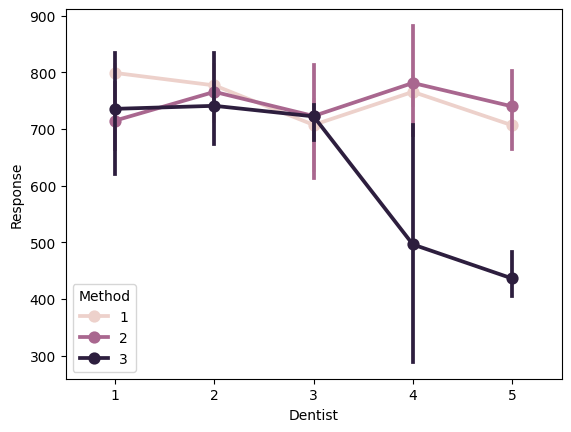

In [ ]:
# First, let's look at the interaction plot with implants done with alloy 1:

sns.pointplot (dataset, x= dataset.loc[dataset['Alloy']==1, 'Dentist'], y= dataset.loc[dataset['Alloy']==1, 'Response'], hue = dataset.loc[dataset['Alloy']==1, 'Method'])
plt.show()

Conclusion (Alloy 1):

- All dentists conduct implants with reasonably similar hardness across first 2 methods. However, the hardness of the implants done by dentists 4 and 5 drops significantly when they use the 3rd method.
- This means the effectivity of the method used strongly depends on the dentist using it.
- This also confirms our previous observations that the hardness of implants is likely not impacted by the dentist performing it but is infact likely to be impacted by the method being used.

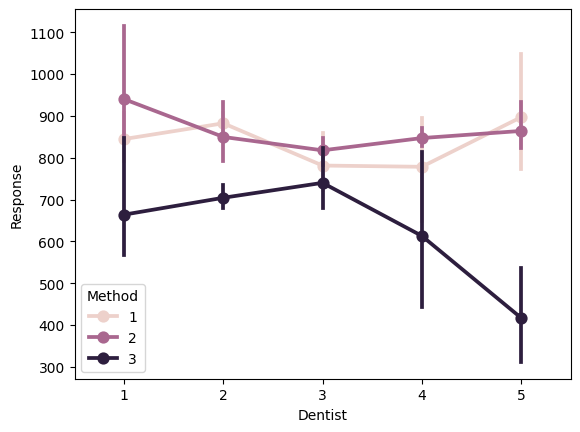

In [ ]:
# Now let's look at the interaction plot with implants done with alloy 2:

sns.pointplot (dataset, x= dataset.loc[dataset['Alloy']==2, 'Dentist'], y= dataset.loc[dataset['Alloy']==2, 'Response'], hue = dataset.loc[dataset['Alloy']==2, 'Method'])
plt.show()

Conclusion (Alloy 2):

- The same patterns as observed with alloy 1 are also present over here. However, the difference that we get with the 3rd method is far more apparent here, and it plays out across all dentists, not just the 4th and 5th.
- This further validates our finding that the method used does in fact impact the hardness of implants performed. The significant difference seen with method 3 might mean it is particularly challenging to use or is suboptimal in some other way.

### **Question 4.4**

How does the hardness of implants vary depending on dentists and methods together?

In [ ]:
# We've seen how hardness is impacted by dentist performing the implant and method being used seperately. Now, lets look at them together.


# Let's check if assumption 3 for conducting ANOVA test is satisfied: (We know from previous tests that assumption 1 is invalid and assumption 2 is valid)

statistic, p_value = levene (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'])
print ("The p_value for levene's test is", p_value)


# Since the p_value is greater than 0.05 (significance level of 5%), we fail to reject the null hypothesis.
# In other words, the population variances are likely equal. So assumption 3 is valid.

The p_value for levene's test is 0.2113847678525659


In [ ]:
# Now let's define our null and alternative hypotheses.

"H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5"                  # This is the null hypothesis. This means the hardness of implant is not impacted by the dentist and method combination that is used.
"Ha: Atleast one of these means is not the same"   # This is the alternative hypothesis. Even if atleast one inequality shows up it holds. This means the hardness of the implant is impacted by atleast one dentist and method combination.

print ("H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5", "\n", "Ha: Atleast one of these means is not the same")

H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5 
 Ha: Atleast one of these means is not the same


In [ ]:
# Running the ANOVA test for Alloy 1:

test_stat, p_value = f_oneway (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'])

print ("The p_value is", p_value)

The p_value is 0.00036907998155865653


Conclusion (Alloy 1)

- Since the p_value of the ANOVA test is smaller than 0.05 (Significance level of 5%), we can reject the null hypothesis.
- We can say that the mean hardness of implants done with Alloy 1 is likely affected by at atleast one combination of dentist and the method they use.
- This result is unsurprising since we've already seen that method 3 is likely not from the same sampling distribution as the other two methods. So when we combine that with dentists, what we get is also not likely to be in the same sampling distribution as the rest.

In [ ]:
# Now let's do for alloy 2.

# Let's check if assumption 3 for conducting ANOVA test is satisfied: (We know from previous tests that assumption 1 is invalid and assumption 2 is valid)

statistic, p_value = levene (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'])
print ("The p_value for levene's test is", p_value)


# Since the p_value is greater than 0.05 (significance level of 5%), we fail to reject the null hypothesis.
# In other words, the population variances are likely equal. So assumption 3 is valid for alloy 2 also.

The p_value for levene's test is 0.7654402577064456


In [ ]:
# The null and alternative hypotheses for alloy 2 will also be the same:

"H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5"                  # This is the null hypothesis. This means the hardness of implant is not impacted by the dentist and method combination that is used.
"Ha: Atleast one of these means is not the same"   # This is the alternative hypothesis. Even if atleast one inequality shows up it holds. This means the hardness of the implant is impacted by atleast one dentist and method combination.

print ("H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5", "\n", "Ha: Atleast one of these means is not the same")

H0: Mu1 = Mu2 = Mu3 = Mu4 = Mu5 
 Ha: Atleast one of these means is not the same


In [ ]:
# Running the ANOVA test for Alloy 2:

test_stat, p_value = f_oneway (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response'])

print ("The p_value is", p_value)

The p_value is 0.0019521790464762058


Conclusion (Alloy 2)

- Since the p_value of the ANOVA test is again smaller than 0.05 (Significance level of 5%), we can reject the null hypothesis.
- We can say that the mean hardness of implants done with Alloy 2 is also likely affected by at atleast one combination of dentist and the method they use.

### **Rough (Ignore)**

In [ ]:
# Let's do for Alloy 1 first.

# We will find the mean hardness for each dentist within the implants done with Alloy 1.

x_bar_1 = ((dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response']).sum()) / ((dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response']).count())
x_bar_2 = ((dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response']).sum()) / ((dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response']).count())
x_bar_3 = ((dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response']).sum()) / ((dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response']).count())
x_bar_4 = ((dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response']).sum()) / ((dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response']).count())
x_bar_5 = ((dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response']).sum()) / ((dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response']).count())

print (round (x_bar_1, 2), round (x_bar_2, 2), round (x_bar_3, 2), round (x_bar_4, 2), round (x_bar_5,2))

749.89 761.22 717.56 681.11 627.67


In [ ]:
# We see that x_bar_3 has a value that's in the middle of the 5 values. Hence, let's build a sampling distribution around that.

x_bar_3 = 717.56
S = ((dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response']).std())
n = 9

x_values = np.linspace (x_bar_3 - 4*S, x_bar_3 + 4*S, 1000)

sampling_distribution = t.pdf (x_values, n-1, x_bar_3, S/np.sqrt(n))

# We will also work with a significance level of 5%. Now, let's define the tolerance range within this distribution.

lower_end = t.ppf (0.025, n-1, x_bar_3, S/np.sqrt(n))
upper_end = t.ppf (0.975, n-1, x_bar_3, S/np.sqrt(n))

print ("Tolerance range is everything between", round (lower_end, 2), "and", round (upper_end, 2), "on the hardness of implants")

# We see from this tolerance range at a 5% significance level that out of all 5 sample means, only x_bar_5 lies outisde the range.
# Nonetheless, we fail to say that ALL sample means satisfactorily fall within the same sampling distribution.
# Hence, we have sufficient evidence to reject the null hypothesis.

Tolerance range is everything between 667.93 and 767.19 on the hardness of implants


Conclusion (Alloy 1):

- Sample mean of atleast one dentist falls outside of tolerance range of sampling distribution as specified by the signifance level.
- This means we have sufficient evidence to reject the null hypothesis.
- We can say that the mean hardness of implants is in fact impacted by atleast one dentist for implants done with Alloy 1.

In [ ]:
# Now let's do for Alloy 2.

# We will find the mean hardness for each dentist within the implants done with Alloy 2.

x_bar_1 = (dataset.loc[(dataset['Dentist']==1) & (dataset['Alloy']==2), 'Response']).mean()
x_bar_2 = (dataset.loc[(dataset['Dentist']==2) & (dataset['Alloy']==2), 'Response']).mean()
x_bar_3 = (dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response']).mean()
x_bar_4 = (dataset.loc[(dataset['Dentist']==4) & (dataset['Alloy']==2), 'Response']).mean()
x_bar_5 = (dataset.loc[(dataset['Dentist']==5) & (dataset['Alloy']==2), 'Response']).mean()

print (round (x_bar_1, 2), round (x_bar_2, 2), round (x_bar_3, 2), round (x_bar_4, 2), round (x_bar_5,2))

816.22 812.11 779.67 746.22 726.11


In [ ]:
# We see that x_bar_3 again has a value that's in the middle of the 5 values. Hence, let's build a sampling distribution around that.

x_bar_3 = 779.67
S = ((dataset.loc[(dataset['Dentist']==3) & (dataset['Alloy']==2), 'Response']).std())
n = 9

x_values = np.linspace (x_bar_3 - 4*S, x_bar_3 + 4*S, 1000)

sampling_distribution = t.pdf (x_values, n-1, x_bar_3, S/np.sqrt(n))

# Now, let's define the tolerance range within this distribution with the same significance level of 5%.

lower_end = t.ppf (0.025, n-1, x_bar_3, S/np.sqrt(n))
upper_end = t.ppf (0.975, n-1, x_bar_3, S/np.sqrt(n))

print ("Tolerance range is everything between", round (lower_end, 2), "and", round (upper_end, 2), "on the hardness of implants")

# Again, we see from this tolerance range at a 5% significance level that out of all 5 sample means, only x_bar_5 lies outisde the range.
# Nonetheless, we fail to say that ALL sample means satisfactorily fall within the same sampling distribution.
# Hence, we have sufficient evidence to reject the null hypothesis for Alloy 2 as well.

Tolerance range is everything between 731.11 and 828.23 on the hardness of implants


Conclusion (Alloy 2):

- Sample mean of atleast one dentist falls outside of tolerance range of sampling distribution as specified by the signifance level.
- This means we have sufficient evidence to reject the null hypothesis.
- We can say that the mean hardness of implants is in fact impacted by atleast one dentist for implants done with Alloy 2 as well.

In [ ]:
# We've seen how hardness is impacted by dentist performing the implant and method being used seperately. Now, lets look at them together.

# Let's define the individual groups for convenience and put them in a dataframe:

group_1 = (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response']).mean()
group_2 = (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response']).mean()
group_3 = (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response']).mean()
group_4 = (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response']).mean()
group_5 = (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response']).mean()
group_6 = (dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response']).mean()
group_7 = (dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response']).mean()
group_8 = (dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response']).mean()
group_9 = (dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response']).mean()
group_10 = (dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response']).mean()
group_11 = (dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response']).mean()
group_12 = (dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response']).mean()
group_13 = (dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response']).mean()
group_14 = (dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response']).mean()
group_15 = (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response']).mean()

groups_names = ["group_1", "group_2", "group_3", "group_4", "group_5", "group_6", "group_7", "group_8", "group_9", "group_10", "group_11", "group_12", "group_13", "group_14", "group_15"]
groups_means = [group_1, group_2, group_3, group_4, group_5, group_6, group_7, group_8, group_9, group_10, group_11, group_12, group_13, group_14, group_15]

alt_dataset = pd.DataFrame()
alt_dataset ['groups_names'] = groups_names
alt_dataset ['groups_means'] = groups_means


# Let's check if assumption 3 for conducting ANOVA test is satisfied: (We know from previous tests that assumption 1 is invalid and assumption 2 is valid)

statistic, p_value = levene (dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==1) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==2) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==1) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==2) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==3) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==4) & (dataset['Alloy']==1), 'Response'], dataset.loc[(dataset['Method']==3) & (dataset['Dentist']==5) & (dataset['Alloy']==1), 'Response'])
print ("The p_value for levene's test is", p_value)


# Since the p_value is greater than 0.05 (significance level of 5%), we fail to reject the null hypothesis.
# In other words, the population variances are likely equal. So assumption 3 is valid.

The p_value for levene's test is 0.2113847678525659


In [ ]:
# Now let's see which method pairs are different from one another by using the Tukey HSD function:

m_comp = pairwise_tukeyhsd(endog = alt_dataset['groups_means'][:5], groups = alt_dataset['groups_names'][:5], alpha = 0.05)
print(m_comp)

# From the output, we again see that method 3 is the one that is different. (It is different from 1 as well as 2, while 1 and 2 are not different from one another)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1  group2 meandiff p-adj lower upper reject
-------------------------------------------------
group_1 group_2    -22.0   nan   nan   nan  False
group_1 group_3 -91.6667   nan   nan   nan  False
group_1 group_4 -33.3333   nan   nan   nan  False
group_1 group_5 -92.3333   nan   nan   nan  False
group_2 group_3 -69.6667   nan   nan   nan  False
group_2 group_4 -11.3333   nan   nan   nan  False
group_2 group_5 -70.3333   nan   nan   nan  False
group_3 group_4  58.3333   nan   nan   nan  False
group_3 group_5  -0.6667   nan   nan   nan  False
group_4 group_5    -59.0   nan   nan   nan  False
-------------------------------------------------


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Now let's see which method pairs are different from one another by using the Tukey HSD function:

m_comp = pairwise_tukeyhsd(endog = alt_dataset['groups_means'][5:10], groups = alt_dataset['groups_names'][5:10], alpha = 0.05)
print(m_comp)

# From the output, we again see that method 3 is the one that is different. (It is different from 1 as well as 2, while 1 and 2 are not different from one another)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
 group1   group2 meandiff p-adj lower upper reject
--------------------------------------------------
group_10 group_6    -25.0   nan   nan   nan  False
group_10 group_7  25.6667   nan   nan   nan  False
group_10 group_8    -17.0   nan   nan   nan  False
group_10 group_9  41.3333   nan   nan   nan  False
 group_6 group_7  50.6667   nan   nan   nan  False
 group_6 group_8      8.0   nan   nan   nan  False
 group_6 group_9  66.3333   nan   nan   nan  False
 group_7 group_8 -42.6667   nan   nan   nan  False
 group_7 group_9  15.6667   nan   nan   nan  False
 group_8 group_9  58.3333   nan   nan   nan  False
--------------------------------------------------


In [ ]:
# Now let's see which method pairs are different from one another by using the Tukey HSD function:

m_comp = pairwise_tukeyhsd(endog = alt_dataset['groups_means'][10:16], groups = alt_dataset['groups_names'][10:16], alpha = 0.05)
print(m_comp)

# From the output, we again see that method 3 is the one that is different. (It is different from 1 as well as 2, while 1 and 2 are not different from one another)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1   group2   meandiff p-adj lower upper reject
----------------------------------------------------
group_11 group_12    5.3333   nan   nan   nan  False
group_11 group_13  -13.3333   nan   nan   nan  False
group_11 group_14 -239.3333   nan   nan   nan  False
group_11 group_15     -29.0   nan   nan   nan  False
group_12 group_13  -18.6667   nan   nan   nan  False
group_12 group_14 -244.6667   nan   nan   nan  False
group_12 group_15  -34.3333   nan   nan   nan  False
group_13 group_14    -226.0   nan   nan   nan  False
group_13 group_15  -15.6667   nan   nan   nan  False
group_14 group_15  210.3333   nan   nan   nan  False
----------------------------------------------------
